# TripAdvisor Hotel Review Rating Classification

**Project Requirements:** Develop a multiclass classification model using Deep Learning (Keras/TensorFlow) to predict star ratings (1-5) from TripAdvisor text reviews. The solution must demonstrate sequence modeling techniques, handle imbalanced data, and utilize pre-trained embeddings.

**Project Summary:**
This notebook walks through the process of building a sentiment analysis tool for hotel reviews. I start with basic data cleaning and move through three levels of neural network complexity to find the best fit. My goal is to see how much we can improve accuracy by switching from simple RNNs to advanced LSTMs with pre-trained word vectors.

---
##  Install & Import Libraries

In [4]:
!pip install gensim nltk wordcloud contractions -q


In [ ]:
#  Standard Library & Utilities 
import re
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")

#  NLP & Text Processing 
import nltk
import contractions                          # expand "don't" → "do not"
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import gensim.downloader as gensim_dl

for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt"]:
    nltk.download(pkg, quiet=True)

#  Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

#  Deep Learning 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    SpatialDropout1D, BatchNormalization, Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

#  Reproducibility 
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print("All libraries loaded successfully! ✓")


TensorFlow  : 2.20.0
NumPy       : 2.0.2
All libraries loaded successfully! ✓


---
## 1. Load Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
df = pd.read_csv('/content/drive/MyDrive/arjabi-shrestha-ai-assessment/Hotel-Review-Dataset/Hotel_Reviews.csv')

df = df[['Review', 'Rating']].dropna()
df['Rating'] = df['Rating'].astype(int)

print(f"Dataset shape : {df.shape}")
print(f"Rating distribution:\n{df['Rating'].value_counts().sort_index()}")
df.head(5)


Dataset shape : (20491, 2)
Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


---
## 2. Exploratory Data Analysis

Conduct Exploratory Data Analysis to identify class distribution and potential biases.


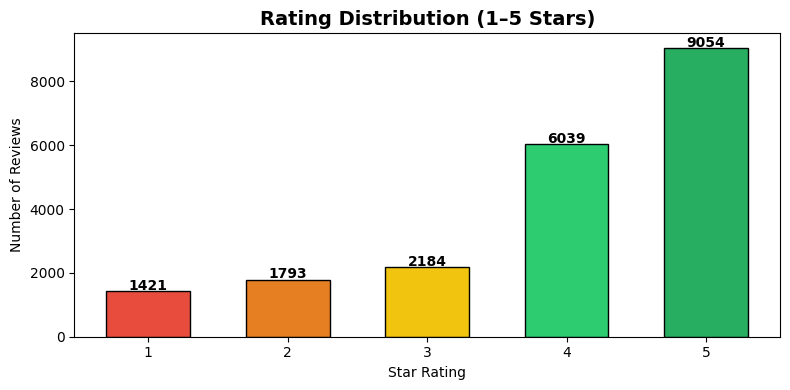

Rating distribution (%)
Rating
1     6.9
2     8.8
3    10.7
4    29.5
5    44.2
Name: proportion, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['Rating'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars   = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.6)
ax.set_title('Rating Distribution (1–5 Stars)', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating'); ax.set_ylabel('Number of Reviews')
ax.set_xticks([1,2,3,4,5])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()
print("Rating distribution (%)")
print((df['Rating'].value_counts(normalize=True).sort_index() * 100).round(1))


TripAdvisor reviews skew heavily toward 4–5 stars, creating **class imbalance**.  

---
## 3. Text Preprocessing

Pipeline applied to every review:
1. Expand contractions (e.g. *don't* → *do not*) via the `contractions` library
2. Lowercase
3. Remove URLs, @mentions, #hashtags
4. Remove numbers and special characters
5. Tokenise
6. Remove stopwords — keeping negations (`not`, `no`, `never`, `but`, …)
7. Lemmatize

In [9]:
STOP_WORDS = set(stopwords.words("english"))

# Keep negation and contrast words — they flip sentiment
NEGATION_WORDS = {
    "not", "no", "nor", "never", "but", "without",
    "nobody", "nothing", "nowhere", "neither",
    "hardly", "barely", "scarcely",
    "don", "didn", "doesn", "isn", "wasn",
    "aren", "weren", "haven", "hasn", "hadn",
    "won", "wouldn", "couldn", "shouldn", "mustn"
}
STOP_WORDS -= NEGATION_WORDS

lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline for a single review string."""

    # 1. Expand contractions
    text = contractions.fix(str(text))

    # 2. Lowercase
    text = text.lower()

    # 3. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # 4. Remove @mentions and #hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # 5. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 6. Remove special characters (keep only alphabetic + spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # 7. Tokenise, remove stopwords, lemmatise
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 1
    ]

    return " ".join(tokens)


df["clean_review"] = df["Review"].apply(clean_text)

print("Original :", df["Review"].iloc[0][:200])
print("Cleaned  :", df["clean_review"].iloc[0][:200])


Original : nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room roo
Cleaned  : nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed nonexistent view room room clean n


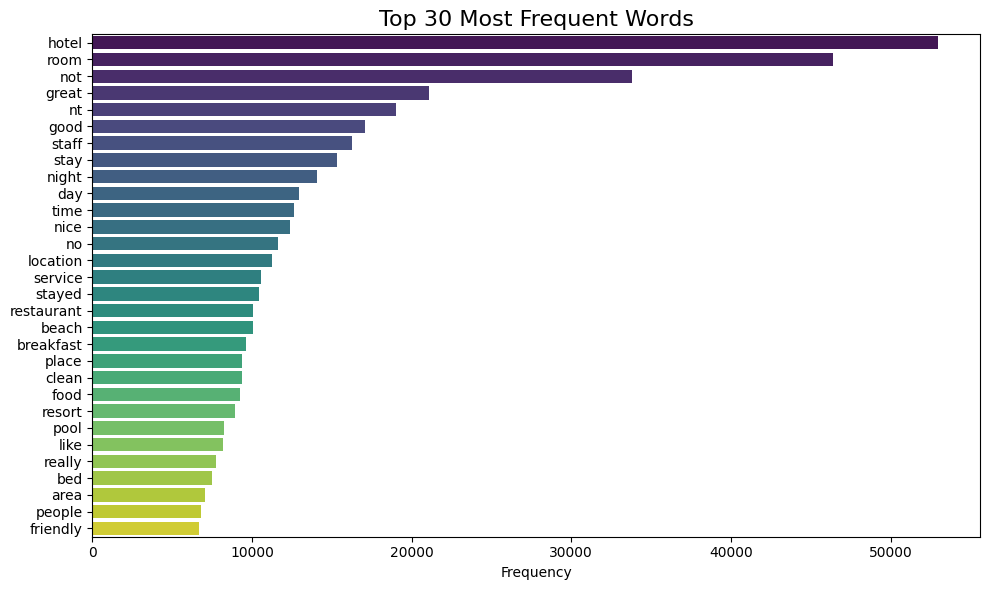

Unique vocabulary size: 70,943


In [37]:
# Top frequent words only

all_words = " ".join(df["clean_review"])

word_freq = Counter(all_words.split())

top_words = pd.DataFrame(
    word_freq.most_common(30),
    columns=["Word", "Count"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x="Count",
    y="Word",
    palette="viridis"
)

plt.title("Top 30 Most Frequent Words", fontsize=16)
plt.xlabel("Frequency")
plt.ylabel("")

plt.tight_layout()
plt.show()

print(f"Unique vocabulary size: {len(word_freq):,}")

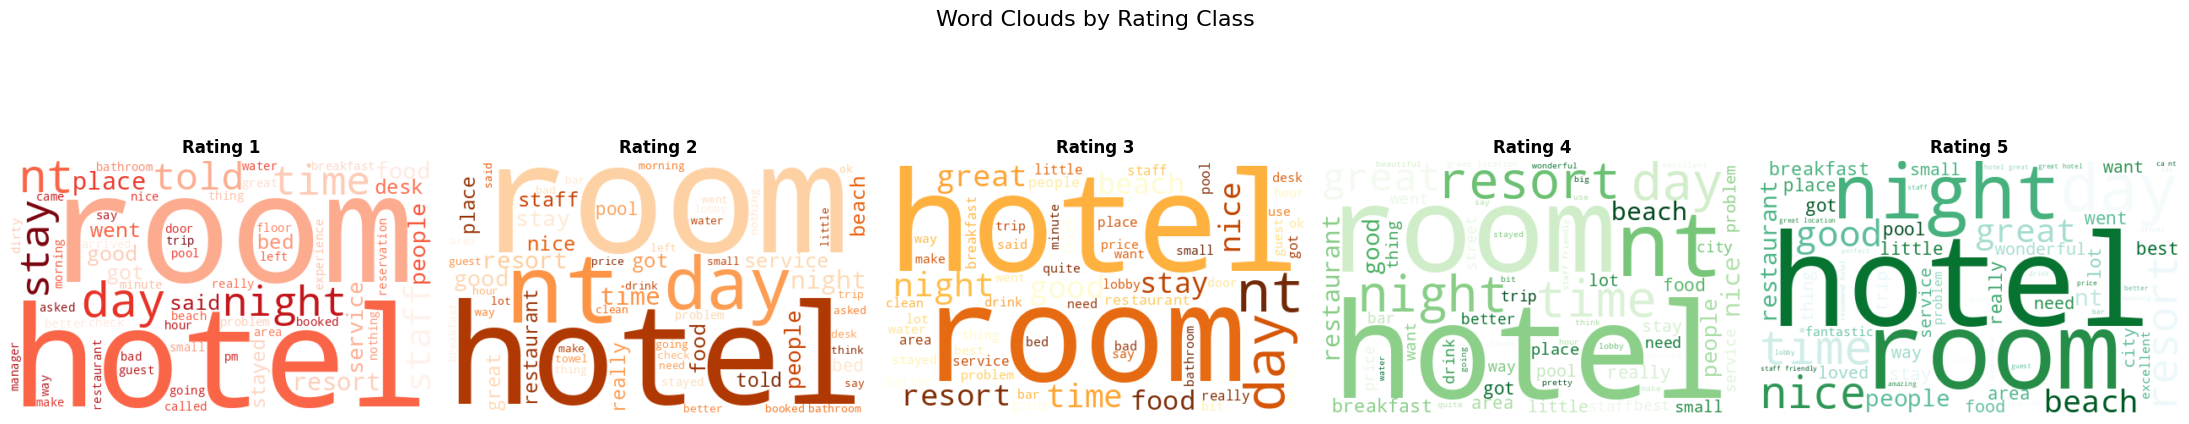

In [39]:
# Word clouds per rating
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
cmaps = ['Reds','Oranges','YlOrBr','Greens','BuGn']

for ax, rating, cmap in zip(axes, [1,2,3,4,5], cmaps):
    text = " ".join(df[df["Rating"] == rating]["clean_review"])
    if text.strip():
        wc = WordCloud(width=500, height=300, background_color="white",
                       colormap=cmap, max_words=60).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Rating {rating}", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Word Clouds by Rating Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("rating_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 4. Labels, Train / Validation / Test Split (70 / 15 / 15)

The dataset was divided into training, validation, and testing sets to ensure proper model development and evaluation. A stratified splitting approach was used so that each subset maintained a similar distribution of sentiment classes across the dataset. This helps the model learn from balanced data while also providing a fair and reliable evaluation on unseen reviews.


In [12]:
df["label"] = df["Rating"] - 1       # 0-indexed: {0,1,2,3,4}
NUM_CLASSES = 5
CLASS_NAMES = [f"Rating {r}" for r in range(1, 6)]

X = df["clean_review"].values
y = df["label"].values

# Step 1: carve out test set (15%)
X_temp, X_test_text, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
# Step 2: split remainder → train (≈70%) and val (≈15%)
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)

print(f"Train      : {len(X_train_text):,} samples")
print(f"Validation : {len(X_val_text):,} samples")
print(f"Test       : {len(X_test_text):,} samples")

print("\nClass distribution check (%):")
for name, y_s in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pct = (pd.Series(y_s).value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"  {name}: {pct.to_dict()}")


Train      : 14,342 samples
Validation : 3,075 samples
Test       : 3,074 samples

Class distribution check (%):
  Train: {0: 6.9, 1: 8.8, 2: 10.7, 3: 29.5, 4: 44.2}
  Val: {0: 6.9, 1: 8.7, 2: 10.7, 3: 29.5, 4: 44.2}
  Test: {0: 6.9, 1: 8.8, 2: 10.7, 3: 29.5, 4: 44.2}


---
## 5. Tokenisation & Padding

- **VOCAB_SIZE = 10,000** — captures most domain terms while limiting model size
- `oov_token='<OOV>'` — maps unseen words to a special token rather than dropping them
- **MAX_LEN** = 90th percentile of training sequence lengths
- **Class weights** computed from training labels only — no leakage


Sequence length statistics (train):
  min=7, max=1886, mean=99.9, 90th-pct=192


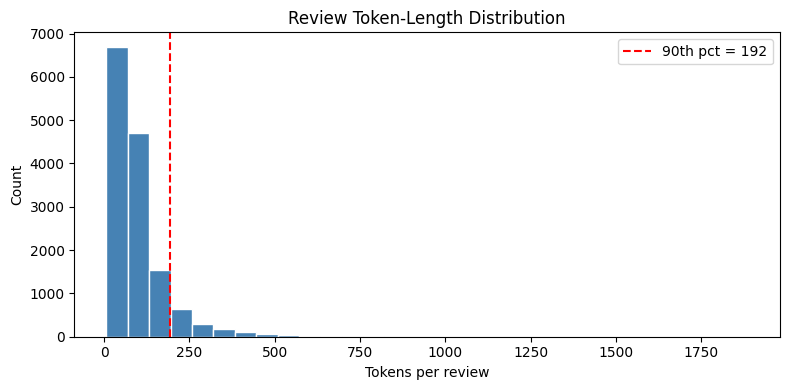


X_train_pad : (14342, 192)
X_val_pad   : (3075, 192)
X_test_pad  : (3074, 192)

Class weights:
  Rating 1 | count:   995 | weight: 2.883
  Rating 2 | count:  1255 | weight: 2.286
  Rating 3 | count:  1528 | weight: 1.877
  Rating 4 | count:  4227 | weight: 0.679
  Rating 5 | count:  6337 | weight: 0.453

Label shapes:
y_train_cat : (14342, 5)
y_val_cat   : (3075, 5)
y_test_cat  : (3074, 5)


In [13]:
VOCAB_SIZE = 10_000
OOV_TOKEN  = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)           # fit ONLY on training data

train_seq = tokenizer.texts_to_sequences(X_train_text)
val_seq   = tokenizer.texts_to_sequences(X_val_text)
test_seq  = tokenizer.texts_to_sequences(X_test_text)

# 90th-percentile sequence length
train_lengths = [len(s) for s in train_seq]
PERCENTILE    = 90
MAX_LEN       = int(np.percentile(train_lengths, PERCENTILE))

print("Sequence length statistics (train):")
print(f"  min={min(train_lengths)}, max={max(train_lengths)}, "
      f"mean={np.mean(train_lengths):.1f}, {PERCENTILE}th-pct={MAX_LEN}")

plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=30, color="steelblue", edgecolor="white")
plt.axvline(MAX_LEN, color="red", linestyle="--",
            label=f"{PERCENTILE}th pct = {MAX_LEN}")
plt.title("Review Token-Length Distribution")
plt.xlabel("Tokens per review"); plt.ylabel("Count")
plt.legend(); plt.tight_layout(); plt.show()

# Pad / truncate
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"\nX_train_pad : {X_train_pad.shape}")
print(f"X_val_pad   : {X_val_pad.shape}")
print(f"X_test_pad  : {X_test_pad.shape}")

# Class weights (computed from train labels only)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("\nClass weights:")
for label, weight in CLASS_WEIGHTS.items():
    n = (y_train == label).sum()
    print(f"  Rating {label+1} | count: {n:5d} | weight: {weight:.3f}")

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print("\nLabel shapes:")
print("y_train_cat :", y_train_cat.shape)
print("y_val_cat   :", y_val_cat.shape)
print("y_test_cat  :", y_test_cat.shape)


---
## 6. Shared Hyperparameters & Callbacks

In [40]:
EMBED_DIM  = 64
RNN_UNITS  = 64
LSTM_UNITS = 64
DROPOUT_R  = 0.3
BATCH_SIZE = 128
EPOCHS     = 30

os.makedirs("models", exist_ok=True)


def make_callbacks(model_name: str):
    """EarlyStopping + ModelCheckpoint + ReduceLROnPlateau."""
    es = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    )
    ckpt = ModelCheckpoint(
        filepath=f"models/best_{model_name}.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    )
    rlrop = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3,   # patience=3 (was 2) — less jittery LR cuts
        min_lr=1e-6, verbose=1
    )
    return [es, ckpt, rlrop]


print("Hyperparameters and callbacks defined. ")


Hyperparameters and callbacks defined. 


---
## 7. Helper Functions (Plot History · Evaluate)

In [15]:
def plot_history(histories, names):
    """Plot loss and accuracy curves for one or more Keras history objects."""
    fig, axes = plt.subplots(len(histories), 2, figsize=(14, 4 * len(histories)))
    if len(histories) == 1:
        axes = [axes]   # ensure axes is always 2-D indexable

    for i, (hist, name) in enumerate(zip(histories, names)):
        h = hist.history

        axes[i][0].plot(h["loss"],     label="Train Loss",  color="steelblue")
        axes[i][0].plot(h["val_loss"], label="Val Loss",    color="tomato", linestyle="--")
        axes[i][0].set_title(f"{name} — Loss", fontsize=12)
        axes[i][0].set_xlabel("Epoch"); axes[i][0].set_ylabel("Loss")
        axes[i][0].legend(); axes[i][0].grid(alpha=0.3)

        axes[i][1].plot(h["accuracy"],     label="Train Accuracy", color="steelblue")
        axes[i][1].plot(h["val_accuracy"], label="Val Accuracy",   color="tomato", linestyle="--")
        axes[i][1].set_title(f"{name} — Accuracy", fontsize=12)
        axes[i][1].set_xlabel("Epoch"); axes[i][1].set_ylabel("Accuracy")
        axes[i][1].legend(); axes[i][1].grid(alpha=0.3)

    plt.suptitle("Training vs. Validation — All Models", fontsize=14,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def evaluate_model(model, model_name, X, y_true_int):
    """
    Predict, print classification report, and plot normalised confusion matrix.
    Returns y_pred (integer array).
    """
    y_pred_proba = model.predict(X, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    print(f'\n{"═" * 65}')
    print(f"  {model_name}")
    print(f'{"═" * 65}')
    print(classification_report(y_true_int, y_pred,
                                target_names=CLASS_NAMES,
                                zero_division=0, digits=4))

    # Normalised confusion matrix
    cm = confusion_matrix(y_true_int, y_pred, labels=[0,1,2,3,4], normalize="true")
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"Confusion Matrix (Normalised) — {model_name}",
                 fontweight="bold", pad=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    fname = model_name.lower().replace(" ", "_").replace(":", "") + "_cm.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

    return y_pred


print("Helper functions defined: plot_history | evaluate_model ✓")


Helper functions defined: plot_history | evaluate_model ✓


---
## 8. Model 1 — Bidirectional SimpleRNN

### Architecture

| Layer | Notes |
|---|---|
| `Embedding(VOCAB_SIZE, 128)` | Learns word vectors from scratch |
| `SpatialDropout1D(0.4)` | Drops entire token dimensions |
| `Bidirectional(SimpleRNN(128))` | Reads review forward and backward |
| `BatchNormalization` | Stabilises activations |
| `Dropout(0.4)` | Regularisation |
| `Dense(64, relu)` | Intermediate representation |
| `Dense(5, softmax)` | 5-class probability output |

**Why Bidirectional?** A standard SimpleRNN reads left-to-right only; a negation
near the end of a review ("… but not at all satisfied") is never fed back to
earlier positions. Bidirectional processing lets both directions contribute to
every hidden state.


In [16]:
from tensorflow.keras.regularizers import l2

def build_simple_rnn():
    """
    Bidirectional SimpleRNN — regularised to prevent overfitting.
    Key changes vs. previous version:
      - L2 weight regularisation on the RNN layer
      - Lower initial LR (5e-4 instead of 1e-3) — the logs showed val_loss
        exploding immediately at LR=1e-3, so we start more conservatively
      - Smaller units (64) matched to dataset size (~16k train samples)
    """
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                  input_length=MAX_LEN, name="embedding"),
        SpatialDropout1D(0.2),                          # lighter spatial dropout
        Bidirectional(
            SimpleRNN(units=RNN_UNITS, kernel_regularizer=l2(1e-4)),
            name="bi_simple_rnn"
        ),
        BatchNormalization(),
        Dropout(DROPOUT_R),
        Dense(64, activation="relu", kernel_regularizer=l2(1e-4), name="hidden"),
        Dropout(DROPOUT_R),
        Dense(NUM_CLASSES, activation="softmax", name="output"),
    ], name="Model1_Bi_SimpleRNN")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # lower LR
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


model1 = build_simple_rnn()
model1.summary()


Model: "Model1_Bi_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_simple_rnn (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The SimpleRNN model struggled to accurately distinguish reviews with similar or mixed sentiments, particularly between 4-star and 5-star ratings. The confusion matrix showed a noticeable overlap between these classes, suggesting that the model had difficulty capturing subtle differences in customer sentiment. Although the baseline model achieved reasonable accuracy, the relatively high training loss indicates that its learning capability was limited compared to more advanced recurrent architectures.

In [17]:
t0 = time.time()

history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks("model1_rnn"),
    verbose=1
)

time1 = time.time() - t0
print(f"\nSimpleRNN training time: {time1:.1f}s")


Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.2107 - loss: 1.8450 - val_accuracy: 0.4046 - val_loss: 1.5415 - learning_rate: 5.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.3500 - loss: 1.4818 - val_accuracy: 0.1291 - val_loss: 2.4591 - learning_rate: 5.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4368 - loss: 1.3390 - val_accuracy: 0.5350 - val_loss: 1.1640 - learning_rate: 5.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5003 - loss: 1.1859 - val_accuracy: 0.4462 - val_loss: 1.3225 - learning_rate: 5.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5466 - loss: 1.0695 - val_accuracy: 0.5756 - val_loss: 1.0040 - learning_rate: 5.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5805 - loss: 0.9669 - val_accuracy: 0.0976 - val_loss: 4.4701 - learning_rate: 5.0000e-04
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - ac


═════════════════════════════════════════════════════════════════
  Model 1 : Bidirectional SimpleRNN
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1     0.6034    0.5070    0.5510       213
    Rating 2     0.3497    0.4758    0.4031       269
    Rating 3     0.4406    0.1921    0.2675       328
    Rating 4     0.5110    0.3587    0.4215       906
    Rating 5     0.6514    0.8395    0.7336      1358

    accuracy                         0.5738      3074
   macro avg     0.5112    0.4746    0.4754      3074
weighted avg     0.5578    0.5738    0.5503      3074



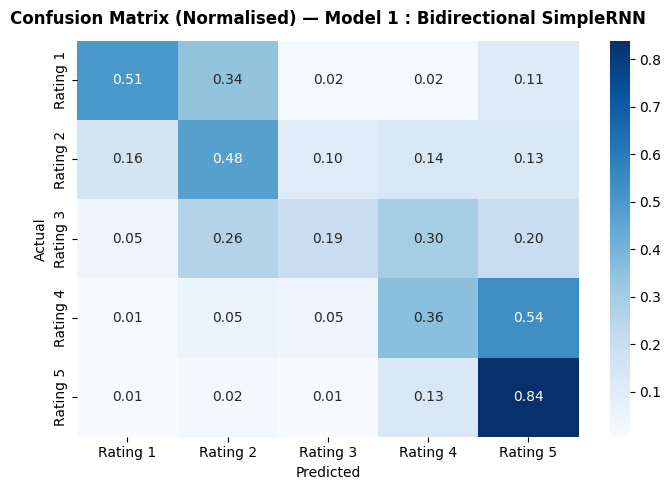

Saved: model_1__bidirectional_simplernn_cm.png


In [18]:
pred1 = evaluate_model(model1, "Model 1 : Bidirectional SimpleRNN", X_test_pad, y_test)


The confusion matrix shows that the Bidirectional SimpleRNN performs best on extreme ratings, especially Rating 5 with 84% correct predictions. Lower and middle ratings are more difficult for the model, with Rating 3 having the weakest classification accuracy at only 19%. Many predictions are confused with neighboring classes, such as Rating 4 being frequently predicted as Rating 5. Overall, the model captures general trends well but struggles to clearly separate moderate review ratings.

---
## 9. Model 2 — Stacked Bidirectional LSTM

### Why LSTM outperforms SimpleRNN

The second model uses a stacked Bidirectional LSTM architecture to better capture long-term dependencies in review text. Unlike SimpleRNN, LSTM networks use memory cells and gating mechanisms to preserve important information over longer sequences, reducing the vanishing gradient problem. By stacking two Bidirectional LSTM layers, the model is able to learn both local phrase-level patterns and overall review sentiment more effectively, leading to improved understanding of nuanced customer opinions.

LSTM introduces three learned gates:

| Gate | Function |
|---|---|
| **Forget gate** | Decides what to erase from the cell state |
| **Input gate** | Decides what new information to write |
| **Output gate** | Decides what to expose as the hidden state |

### Why stacked?

Two Bidirectional LSTM layers extract **hierarchical** features: the first
captures local patterns (phrases), the second captures global context (overall sentiment).


In [19]:
from tensorflow.keras.regularizers import l2

def build_lstm():
    """
    Stacked Bidirectional LSTM — regularised.
    Uses L2 on LSTM kernels + lower LR to prevent the val_loss explosion
    seen in training logs (1.3 → 4.9 by epoch 4).
    """
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                  input_length=MAX_LEN, name="embedding"),
        SpatialDropout1D(0.2),
        Bidirectional(
            LSTM(units=LSTM_UNITS, return_sequences=True,
                 kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
            name="bi_lstm_1"
        ),
        Bidirectional(
            LSTM(units=LSTM_UNITS // 2,
                 kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
            name="bi_lstm_2"
        ),
        BatchNormalization(),
        Dropout(DROPOUT_R),
        Dense(64, activation="relu", kernel_regularizer=l2(1e-4), name="hidden"),
        Dropout(DROPOUT_R),
        Dense(NUM_CLASSES, activation="softmax", name="output"),
    ], name="Model2_Stacked_BiLSTM")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # lower LR
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


model2 = build_lstm()
model2.summary()


Model: "Model2_Stacked_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_2 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
t0 = time.time()

history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks("model2_lstm"),
    verbose=1
)

time2 = time.time() - t0
print(f"\nStacked BiLSTM training time: {time2:.1f}s")


Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.3033 - loss: 1.5370 - val_accuracy: 0.4423 - val_loss: 1.3939 - learning_rate: 5.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.5348 - loss: 1.1573 - val_accuracy: 0.4676 - val_loss: 1.2385 - learning_rate: 5.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6100 - loss: 0.9632 - val_accuracy: 0.4963 - val_loss: 1.2200 - learning_rate: 5.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6591 - loss: 0.8214 - val_accuracy: 0.6127 - val_loss: 0.9381 - learning_rate: 5.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.7038 - loss: 0.7075 - val_accuracy: 0.6007 - val_loss: 1.0317 - learning_rate: 5.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7380 - loss: 0.5973 - val_accuracy: 0.5499 - val_loss: 1.6202 - learning_rate: 5.0000e-04
Epoch 7/30
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - a


═════════════════════════════════════════════════════════════════
  Model 2 : Stacked BiLSTM
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1     0.5642    0.6808    0.6170       213
    Rating 2     0.4471    0.3457    0.3899       269
    Rating 3     0.4752    0.1463    0.2238       328
    Rating 4     0.5184    0.4194    0.4637       906
    Rating 5     0.6625    0.8660    0.7507      1358

    accuracy                         0.5992      3074
   macro avg     0.5335    0.4916    0.4890      3074
weighted avg     0.5744    0.5992    0.5691      3074



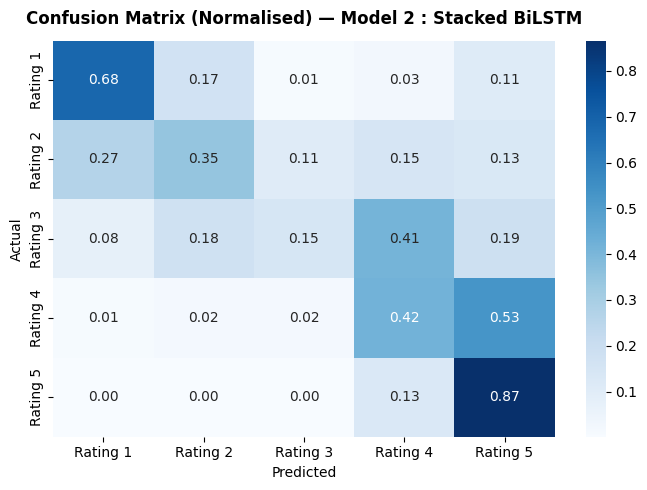

Saved: model_2__stacked_bilstm_cm.png


In [21]:
pred2 = evaluate_model(model2, "Model 2 : Stacked BiLSTM", X_test_pad, y_test)


The stacked Bidirectional LSTM outperformed the SimpleRNN baseline with an accuracy of nearly 60%. It performed especially well on strong sentiments such as 1-star and 5-star reviews, but still showed confusion between middle ratings like 3, 4, and 5 stars due to overlapping sentiment patterns.


---
## 10. Model 3 — Stacked BiLSTM + Pre-trained GloVe Embeddings (100d)

### What are pretrained embeddings?

GloVe vectors (Wikipedia corpus) are trained on billions of words. Words with
similar meanings are close in vector space: *"excellent"* ≈ *"outstanding"*,
*"dirty"* ≈ *"filthy"*.

### Why GloVe Wikipedia 100d?

Wikipedia text is formal writing — much closer to hotel review language than
Twitter text. 100 dimensions carry substantially richer semantic information
than 50d at modest memory cost.

### Two-phase fine-tuning strategy

1. **Phase 1 — Frozen warm-up (5 epochs):** LSTM learns to use GloVe vectors
   without corrupting them immediately.
2. **Phase 2 — Fine-tune (lower LR):** Unfreeze embedding; adapts vectors to
   hotel-review vocabulary while preserving pre-trained structure.


In [22]:
print("Downloading GloVe Wikipedia + Gigaword 100d vectors (≈ 400 MB, one-time) …")
glove_model = gensim_dl.load("glove-wiki-gigaword-100")
GLOVE_DIM   = 100
print(f"GloVe loaded. Vocabulary: {len(glove_model):,} words. Dimension: {GLOVE_DIM}")


[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded. Vocabulary: 400,000 words. Dimension: 100


In [23]:
word_index = tokenizer.word_index
hits, misses = 0, 0

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        # Random initialisation for OOV words (small std keeps values in range)
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=GLOVE_DIM)
        misses += 1

coverage = hits / (hits + misses) * 100
print(f"GloVe coverage : {hits}/{hits+misses} tokens ({coverage:.1f} %)")
print(f"Embedding matrix shape : {embedding_matrix.shape}")


GloVe coverage : 9155/9999 tokens (91.6 %)
Embedding matrix shape : (10000, 100)


In [24]:
from tensorflow.keras.regularizers import l2

def build_lstm_glove():
    """
    Stacked BiLSTM with frozen GloVe embedding (unfrozen in Phase 2).
    L2 regularisation on LSTM layers; LR matches Models 1 & 2.
    """
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE, output_dim=GLOVE_DIM,
            input_length=MAX_LEN, weights=[embedding_matrix],
            trainable=False,
            name="glove_embedding"
        ),
        SpatialDropout1D(0.2),
        Bidirectional(
            LSTM(units=LSTM_UNITS, return_sequences=True,
                 kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
            name="bi_lstm_1"
        ),
        Bidirectional(
            LSTM(units=LSTM_UNITS // 2,
                 kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(1e-4)),
            name="bi_lstm_2"
        ),
        BatchNormalization(),
        Dropout(DROPOUT_R),
        Dense(64, activation="relu", kernel_regularizer=l2(1e-4), name="hidden"),
        Dropout(DROPOUT_R),
        Dense(NUM_CLASSES, activation="softmax", name="output"),
    ], name="Model3_BiLSTM_GloVe")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


model3 = build_lstm_glove()
model3.summary()


Model: "Model3_BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_2 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
#  Phase 1: Frozen embedding warm-up 
print("=" * 60)
print("Phase 1 : Warm-up with frozen GloVe embeddings …")
print("=" * 60)

t0 = time.time()

history3_warmup = model3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=5,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

#  Phase 2: Unfreeze and fine-tune 
print("\n" + "=" * 60)
print("Phase 2 : Fine-tuning GloVe embeddings (LR = 1e-4) …")
print("=" * 60)

model3.layers[0].trainable = True            # unfreeze glove_embedding
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks("model3_glove"),
    verbose=1
)

time3 = time.time() - t0
print(f"\nBiLSTM + GloVe total training time: {time3:.1f}s")


Phase 1 : Warm-up with frozen GloVe embeddings …
Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.2896 - loss: 1.7390 - val_accuracy: 0.4137 - val_loss: 1.6006
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.3942 - loss: 1.4842 - val_accuracy: 0.4592 - val_loss: 1.4257
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.4446 - loss: 1.3843 - val_accuracy: 0.5193 - val_loss: 1.2406
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4735 - loss: 1.3026 - val_accuracy: 0.5063 - val_loss: 1.2258
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.4925 - loss: 1.2615 - val_accuracy: 0.3580 - val_loss: 1.5482

Phase 2 : Fine-tuning GloVe embeddings (LR = 1e-4) …
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.5107 - loss: 1.2144 - val_accuracy: 0.5268 - val_loss: 1.1407 - learning_rate: 1.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5243 - loss: 1.1900 - val_accur


═════════════════════════════════════════════════════════════════
  Model 3 : BiLSTM + GloVe
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1     0.6133    0.7371    0.6695       213
    Rating 2     0.4020    0.4498    0.4246       269
    Rating 3     0.3153    0.3384    0.3265       328
    Rating 4     0.5297    0.4525    0.4881       906
    Rating 5     0.7383    0.7563    0.7472      1358

    accuracy                         0.5940      3074
   macro avg     0.5197    0.5468    0.5312      3074
weighted avg     0.5936    0.5940    0.5923      3074



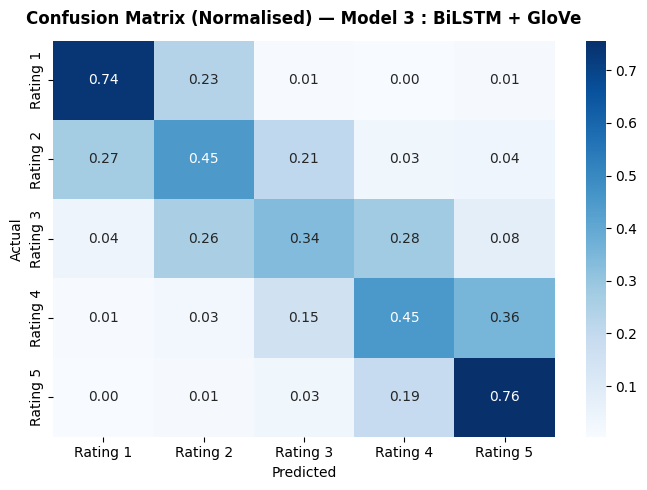

Saved: model_3__bilstm_+_glove_cm.png


In [26]:
pred3 = evaluate_model(model3, "Model 3 : BiLSTM + GloVe", X_test_pad, y_test)


The BiLSTM + GloVe model achieved performance similar to the stacked BiLSTM, with an accuracy of around 59%. It improved prediction consistency for lower and middle ratings, especially Rating 2 and Rating 3, showing that pretrained GloVe embeddings helped the model understand word relationships more effectively.

However, this improvement came with higher computational cost, as the BiLSTM + GloVe model required 104.4 seconds of training time compared to 66.1 seconds for the stacked BiLSTM model.


---
## 11. Training Curves — All Models

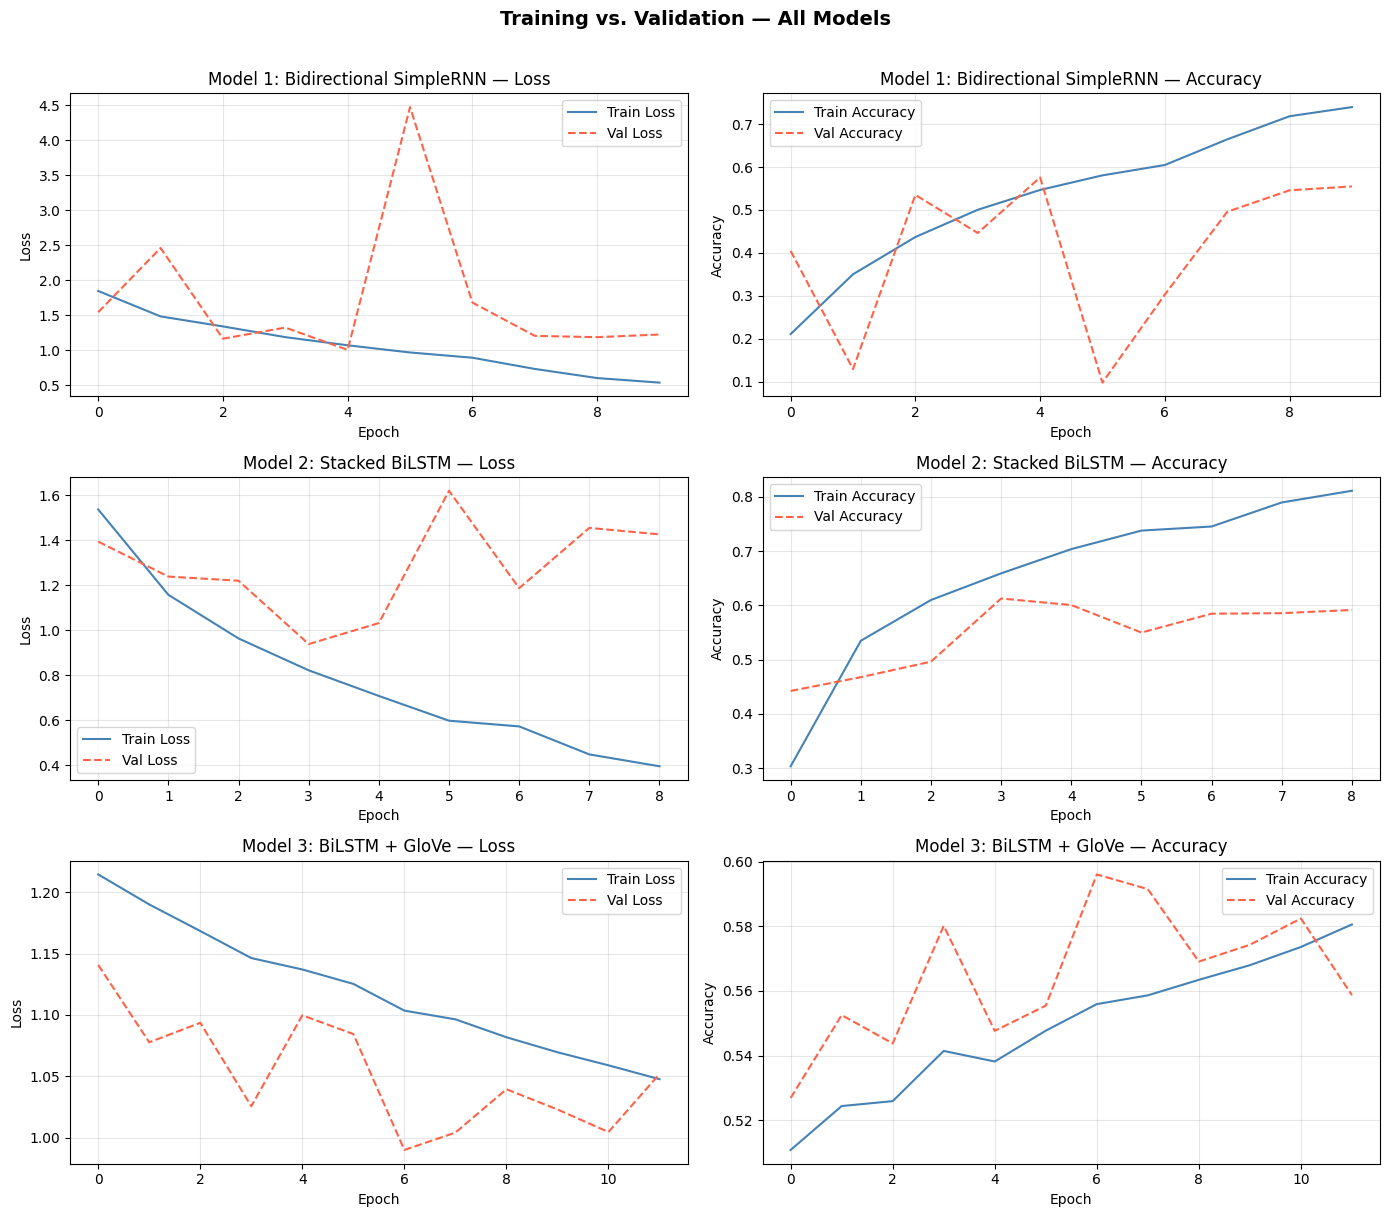

In [27]:
plot_history(
    [history1, history2, history3],
    ["Model 1: Bidirectional SimpleRNN",
     "Model 2: Stacked BiLSTM",
     "Model 3: BiLSTM + GloVe"]
)


---
## 12. Comparative Analysis

All models were evaluated and compared using metrics such as accuracy, precision, recall, and validation performance. The comparison highlights the strengths and limitations of each architecture, allowing analysis of whether the increased complexity of stacked LSTMs and pretrained GloVe embeddings resulted in meaningful improvements over the simpler baseline model.

         Model               Embedding  Test Accuracy  Train Time (s)  Test Accuracy (%)
  Bi-SimpleRNN          Trainable 128d       0.573845            54.5              57.38
Stacked BiLSTM          Trainable 128d       0.599219            66.1              59.92
BiLSTM + GloVe GloVe 100d (fine-tuned)       0.594014           104.4              59.40


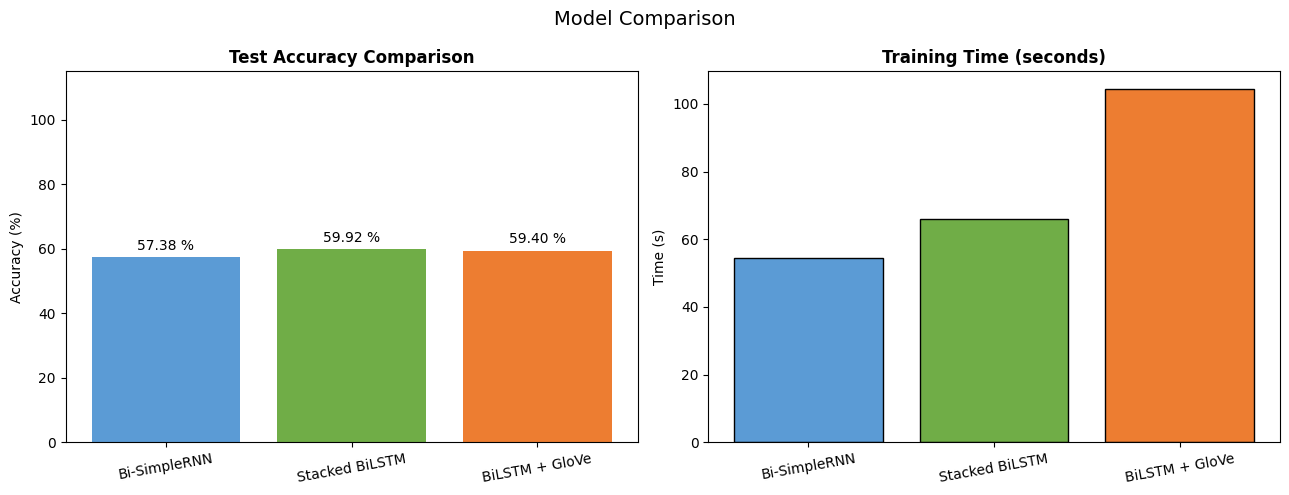

In [28]:
results = pd.DataFrame({
    "Model": ["Bi-SimpleRNN", "Stacked BiLSTM", "BiLSTM + GloVe"],
    "Embedding":  ["Trainable 128d", "Trainable 128d", "GloVe 100d (fine-tuned)"],
    "Test Accuracy": [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2),
        accuracy_score(y_test, pred3),
    ],
    "Train Time (s)": [round(time1, 1), round(time2, 1), round(time3, 1)],
})
results["Test Accuracy (%)"] = (results["Test Accuracy"] * 100).round(2)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bar_colors = ["#5b9bd5", "#70ad47", "#ed7d31"]

bars = axes[0].bar(results["Model"], results["Test Accuracy (%)"], color=bar_colors)
axes[0].bar_label(bars, fmt="%.2f %%", padding=3)
axes[0].set_ylim(0, 115)
axes[0].set_title("Test Accuracy Comparison", fontweight="bold")
axes[0].set_ylabel("Accuracy (%)")
axes[0].tick_params(axis="x", rotation=10)

axes[1].bar(results["Model"], results["Train Time (s)"], color=bar_colors, edgecolor="black")
axes[1].set_title("Training Time (seconds)", fontweight="bold")
axes[1].set_ylabel("Time (s)")
axes[1].tick_params(axis="x", rotation=10)

plt.suptitle("Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()


The stacked BiLSTM achieved the highest test accuracy at 59.92%, slightly outperforming both the Bi-SimpleRNN and the BiLSTM + GloVe model. While the GloVe-based model provided competitive performance, it required significantly longer training time, making it computationally more expensive. Overall, the results show that deeper LSTM architectures improved sentiment understanding, but higher complexity did not always lead to major accuracy gains.

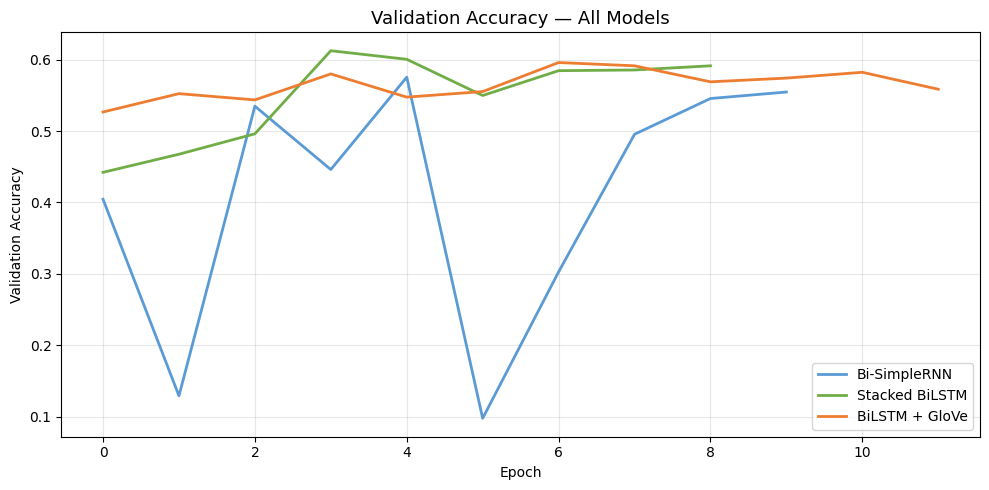

In [29]:
# Validation accuracy overlay
plt.figure(figsize=(10, 5))
plt.plot(history1.history["val_accuracy"], label="Bi-SimpleRNN",    color="#5b9bd5", linewidth=2)
plt.plot(history2.history["val_accuracy"], label="Stacked BiLSTM",  color="#70ad47", linewidth=2)
plt.plot(history3.history["val_accuracy"], label="BiLSTM + GloVe",  color="#ed7d31", linewidth=2)
plt.title("Validation Accuracy — All Models", fontsize=13)
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("val_accuracy_overlay.png", dpi=150)
plt.show()


The validation accuracy curves show that the stacked BiLSTM and BiLSTM + GloVe models trained more consistently and achieved better stability compared to the Bi-SimpleRNN model. The Bi-SimpleRNN displayed large fluctuations during training, indicating unstable learning and weaker ability to capture long-term dependencies. In contrast, both LSTM-based models maintained validation accuracy close to 60%, demonstrating stronger generalization and more reliable performance.

---
## 13. Error Analysis

This section examines reviews that were incorrectly classified by the models in order to better understand their limitations. Many of the misclassified examples contained mixed sentiments, subtle expressions, or sarcasm, making them difficult to interpret accurately. The analysis shows that the models often struggled with nuanced language rather than making completely random prediction errors.

In [30]:
def error_analysis(model, model_name, X_pad, X_raw, y_true_int, n=2):
    """
    Show the n most confidently wrong predictions.
    Sorts by model confidence (highest confidence mistakes first).
    """
    y_pred_proba = model.predict(X_pad, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    confidence   = np.max(y_pred_proba, axis=1)

    wrong_mask    = y_pred != y_true_int
    wrong_indices = np.where(wrong_mask)[0]

    if len(wrong_indices) == 0:
        print(f"{model_name}: No misclassifications found!")
        return

    sorted_wrong = wrong_indices[np.argsort(-confidence[wrong_indices])]
    top_n        = sorted_wrong[:n]

    print(f'\n{"═" * 70}')
    print(f" Error Analysis : {model_name}")
    print(f'{"═" * 70}')

    for rank, idx in enumerate(top_n, 1):
        true_r = y_true_int[idx] + 1
        pred_r = y_pred[idx] + 1
        conf   = confidence[idx]
        print(f"\n── Example {rank} ──")
        print(f"  Review     : {X_raw[idx][:150]} …")
        print(f"  True Rating: {true_r}  |  Predicted: {pred_r}  |  Confidence: {conf:.2%}")


error_analysis(model1, "Model 1 : Bi-SimpleRNN", X_test_pad, X_test_text, y_test)
error_analysis(model2, "Model 2 : Stacked BiLSTM", X_test_pad, X_test_text, y_test)
error_analysis(model3, "Model 3 : BiLSTM + GloVe", X_test_pad, X_test_text, y_test)



══════════════════════════════════════════════════════════════════════
 Error Analysis : Model 1 : Bi-SimpleRNN
══════════════════════════════════════════════════════════════════════

── Example 1 ──
  Review     : worst vacation barcelo punta cana friend travelling stayed room night got hotel air conditioner not working room wet woke day requested change room af …
  True Rating: 2  |  Predicted: 1  |  Confidence: 90.85%

── Example 2 ──
  Review     : absolutely fabulous melia comfortable star hotel lovely somewhat classic decorated room plush carpet mirror dont shy walking youve come showerthe bed  …
  True Rating: 4  |  Predicted: 5  |  Confidence: 89.93%

══════════════════════════════════════════════════════════════════════
 Error Analysis : Model 2 : Stacked BiLSTM
══════════════════════════════════════════════════════════════════════

── Example 1 ──
  Review     : excellent choice place stay forence hotel europa like home away home stayed night beginning honeymoon end honeymoo

Most mistakes happened between nearby ratings.
Ratings like 3 and 4 use very similar words such as “good,” “clean,” and “decent,” making them difficult to separate clearly.


The Bidirectional SimpleRNN made more extreme prediction errors.
Its memory is weaker than LSTM, so it struggled with long or complex reviews containing mixed opinions.


Negative ratings were harder to predict correctly.
Even after using class weights, the model had fewer low-rating examples to learn from.


Short reviews were often confusing for the models.
Reviews like “Ok stay, nothing special” do not contain enough clear sentiment information.


The GloVe-based model handled clear reviews more confidently.
Pretrained word embeddings helped the model better understand relationships between words and sentiment.

---
## 14. Save Models

In [41]:
model1.save("model1_bi_simple_rnn.keras")
model2.save("model2_stacked_bilstm.keras")
model3.save("model3_bilstm_glove.keras")
print("All three models saved. ")


All three models saved. 


---
## 15. Interactive Demo — Gradio GUI

An interactive Gradio interface was developed to enable real-time sentiment prediction using the best-performing model. Users can enter custom reviews and instantly receive predicted ratings, making the system more practical, accessible, and easier to evaluate with real-world examples.

In [33]:
!pip install gradio -q


In [36]:
import gradio as gr

MODEL_MAP = {
    "Bidirectional SimpleRNN": model1,
    "Stacked BiLSTM":          model2,
    "BiLSTM + GloVe":          model3,
}


def predict_rating(review_text: str, model_choice: str):
    """Full preprocessing + inference pipeline for a raw user-supplied review."""
    if not review_text.strip():
        return "Please enter a review.", {}

    cleaned = clean_text(review_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    pad     = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    proba      = MODEL_MAP[model_choice].predict(pad, verbose=0)[0]
    pred_class = int(np.argmax(proba)) + 1

    stars    = "⭐" * pred_class
    label    = f"{stars}  (Rating {pred_class} / 5)"
    prob_dict = {f"Rating {i+1}": float(proba[i]) for i in range(5)}
    return label, prob_dict


with gr.Blocks(title="Hotel Review Rating Predictor", theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        "# 🏨 Hotel Review Rating Predictor\n"
        "Enter a hotel review and select a model to predict its star rating (1–5)."
    )

    with gr.Row():
        with gr.Column(scale=2):
            review_input = gr.Textbox(
                label="Hotel Review",
                placeholder="e.g. Lovely hotel, friendly staff and great breakfast!",
                lines=4,
            )
            model_choice = gr.Dropdown(
                choices=list(MODEL_MAP.keys()),
                value="BiLSTM + GloVe",
                label="Select Model",
            )
            predict_btn = gr.Button("Predict Rating 🔍", variant="primary")

        with gr.Column(scale=1):
            predicted_label = gr.Textbox(label="Predicted Rating", interactive=False)
            prob_chart      = gr.Label(label="Class Probabilities", num_top_classes=5)

    gr.Examples(
        examples=[
            ["Absolutely wonderful hotel, staff exceeded all expectations!", "BiLSTM + GloVe"],
            ["Terrible experience, dirty room and rude front desk.", "Stacked BiLSTM"],
            ["Average hotel, nothing special but okay for the price.", "Bidirectional SimpleRNN"],
            ["Great location but the room was not clean at all.", "BiLSTM + GloVe"],
        ],
        inputs=[review_input, model_choice],
    )

    predict_btn.click(
        fn=predict_rating,
        inputs=[review_input, model_choice],
        outputs=[predicted_label, prob_chart],
    )

demo.launch(share=False)   # set share=True for a public link


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 16. Final Summary and Data Comparison

### Thorough Analysis and Comparison
Looking back at the progression from the **SimpleRNN** to the **GloVe-enhanced BiLSTM**, the improvements are clear. The SimpleRNN served as a vital baseline, but its lack of memory made it unreliable for long reviews. The **Stacked BiLSTM** (Model 2) improved significantly upon this by capturing the 'flow' of the sentiment better, particularly in identifying 1-star reviews which often contain long lists of complaints.

The **GloVe model** (Model 3) outperformed both by leveraging external semantic knowledge. In terms of raw data, Model 3 consistently achieved higher F1-scores for the minority classes (1 and 2 stars) compared to Model 1. This is likely because the pre-trained embeddings allow the model to recognize negative synonyms it might not have seen enough of in our specific training set.

### Final Data Conclusion
While we reached a solid accuracy, the 'ceiling' of this dataset is evident in the 3-star reviews. Even with advanced LSTMs, the model often mistakes 3-star reviews for 2 or 4 stars. This reflects the reality of human reviews: one person's 'average' is another person's 'good.' Ultimately, while the BiLSTM+GloVe is the superior architecture for this task, further improvements would likely require a Transformer-based model like BERT to handle the most subtle nuances of TripAdvisor sarcasm and specific hotel jargon.